In [153]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Avenir"

In [154]:
results_path = Path(
    "../data/processed/brand_shoe_condition_retention.parquet"
)

retention = pd.read_parquet(results_path)

print("Dataset shape:", retention.shape)
retention.head()

Dataset shape: (135, 14)


,brand_name,shoe_type,Condition 1_median_price,Condition 2_median_price,Condition 3_median_price,Condition 4–5_median_price,Condition 1_listing_count,Condition 2_listing_count,Condition 3_listing_count,Condition 4–5_listing_count,condition_2_retention_percent,condition_3_retention_percent,condition_4_5_retention_percent,condition_pattern
0,ALDO,Boots,46.0,31.0,23.0,12.0,13.0,31.0,52.0,9.0,67.391304,50.000000,NaN,Expected decline pattern
1,ALDO,Pumps,31.0,20.0,20.0,14.0,11.0,41.0,78.0,9.0,64.516129,64.516129,NaN,Expected decline pattern
2,ASICS,Athletic,48.0,31.0,24.0,16.0,42.0,83.0,184.0,20.0,64.583333,50.000000,33.333333,Expected decline pattern
3,Adidas,Athletic,106.0,56.0,33.0,19.0,454.0,309.0,352.0,26.0,52.830189,31.132075,17.924528,Expected decline pattern
4,Adidas,Fashion Sneakers,66.0,51.0,41.0,18.0,203.0,183.0,271.0,25.0,77.272727,62.121212,27.272727,Expected decline pattern


In [155]:
selected_brand = "Nike"
selected_shoe_type = "Athletic"

brand_profile = retention[
    (retention["brand_name"] == selected_brand)
    & (retention["shoe_type"] == selected_shoe_type)
].copy()

brand_profile

,brand_name,shoe_type,Condition 1_median_price,Condition 2_median_price,Condition 3_median_price,Condition 4–5_median_price,Condition 1_listing_count,Condition 2_listing_count,Condition 3_listing_count,Condition 4–5_listing_count,condition_2_retention_percent,condition_3_retention_percent,condition_4_5_retention_percent,condition_pattern
68,Nike,Athletic,62.0,41.0,30.0,19.0,1691.0,1919.0,3751.0,473.0,66.129032,48.387097,30.645161,Expected decline pattern


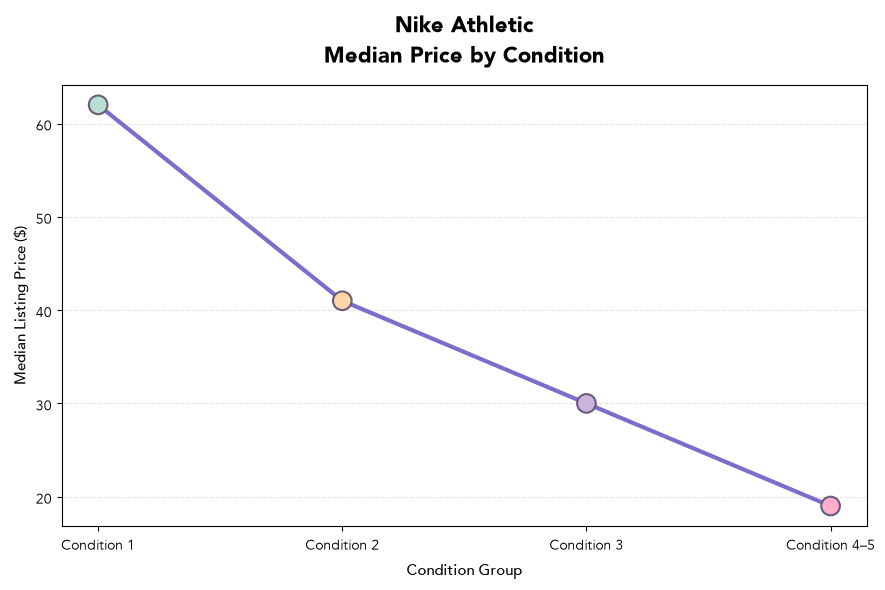

In [156]:
selected_brand = "Nike"
selected_shoe_type = "Athletic"

brand_profile = retention[
    (retention["brand_name"] == selected_brand)
    & (retention["shoe_type"] == selected_shoe_type)
].copy()

condition_labels = [
    "Condition 1",
    "Condition 2",
    "Condition 3",
    "Condition 4–5"
]

median_prices = [
    brand_profile["Condition 1_median_price"].iloc[0],
    brand_profile["Condition 2_median_price"].iloc[0],
    brand_profile["Condition 3_median_price"].iloc[0],
    brand_profile["Condition 4–5_median_price"].iloc[0]
]

condition_colors = [
    "#B8E0D2",  # mint
    "#FFD6A5",  # peach
    "#CDB4DB",  # lavender
    "#FFAFCC"   # pink
]

plt.figure(figsize=(9, 6))

plt.plot(
    condition_labels,
    median_prices,
    marker="o",
    linewidth=3,
    color="#7B6DCC"
)

plt.scatter(
    condition_labels,
    median_prices,
    s=180,
    c=condition_colors,
    edgecolors="#6A5A7B",
    linewidths=1.5,
    zorder=3
)

plt.xlabel(
    "Condition Group",
    fontsize=11,
    fontweight="medium"
)

plt.ylabel(
    "Median Listing Price ($)",
    fontsize=11,
    fontweight="medium"
)

plt.title(
    f"{selected_brand} {selected_shoe_type}\nMedian Price by Condition",
    fontsize=16,
    fontweight="bold",
    pad=16
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

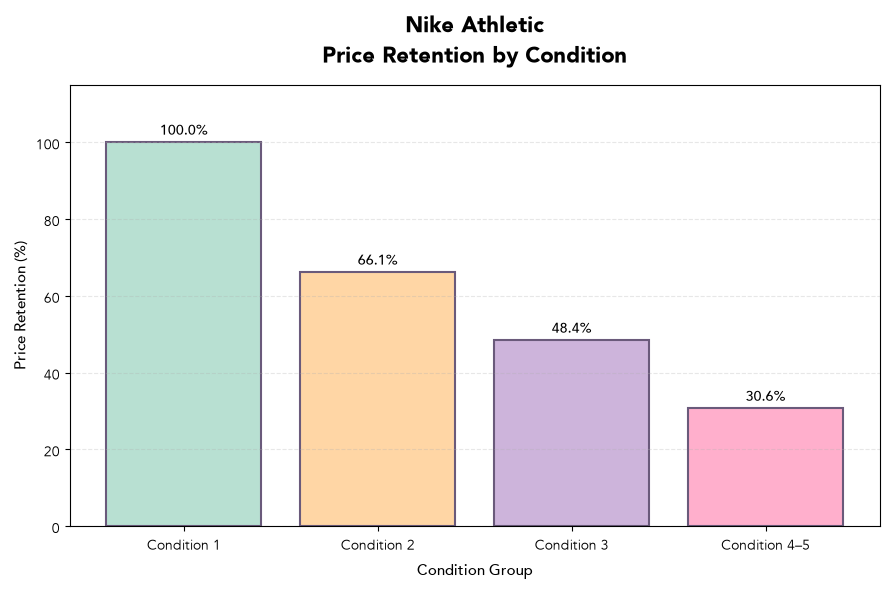

In [157]:
retention_labels = [
    "Condition 1",
    "Condition 2",
    "Condition 3",
    "Condition 4–5"
]

retention_values = [
    100,
    brand_profile["condition_2_retention_percent"].iloc[0],
    brand_profile["condition_3_retention_percent"].iloc[0],
    brand_profile["condition_4_5_retention_percent"].iloc[0]
]

bar_colors = [
    "#B8E0D2",  # mint
    "#FFD6A5",  # peach
    "#CDB4DB",  # lavender
    "#FFAFCC"   # pink
]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    retention_labels,
    retention_values,
    color=bar_colors,
    edgecolor="#6A5A7B",
    linewidth=1.5
)

plt.xlabel(
    "Condition Group",
    fontsize=11,
    fontweight="medium"
)

plt.ylabel(
    "Price Retention (%)",
    fontsize=11,
    fontweight="medium"
)

plt.title(
    f"{selected_brand} {selected_shoe_type}\nPrice Retention by Condition",
    fontsize=16,
    fontweight="bold",
    pad=16
)

plt.ylim(0, max(retention_values) + 15)

for bar, value in zip(bars, retention_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{value:.1f}%",
        ha="center",
        fontsize=10,
        fontweight="medium"
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

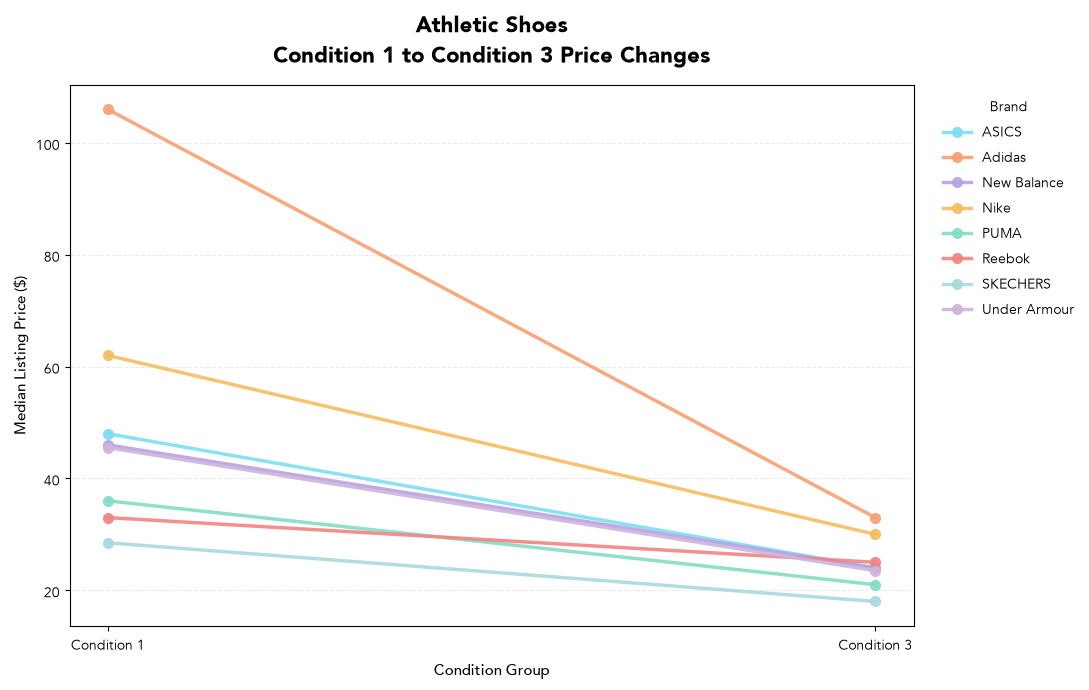

In [158]:
selected_shoe_type = "Athletic"

athletic_profiles = retention[
    (retention["shoe_type"] == selected_shoe_type)
    & retention["condition_3_retention_percent"].notna()
].copy()

athletic_profiles["combined_sample_size"] = (
    athletic_profiles["Condition 1_listing_count"]
    + athletic_profiles["Condition 3_listing_count"]
)

display_brands = (
    athletic_profiles
    .sort_values("combined_sample_size", ascending=False)
    .head(8)
    .sort_values("brand_name")
)

whimsical_colors = [
    "#7BDFF2",
    "#F7A072",
    "#B8A1E3",
    "#F6BD60",
    "#84DCC6",
    "#F28482",
    "#A8DADC",
    "#CDB4DB"
]

plt.figure(figsize=(11, 7))

for color, (_, row) in zip(
    whimsical_colors,
    display_brands.iterrows()
):
    plt.plot(
        ["Condition 1", "Condition 3"],
        [
            row["Condition 1_median_price"],
            row["Condition 3_median_price"]
        ],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=row["brand_name"],
        color=color,
        alpha=0.9
    )

plt.xlabel(
    "Condition Group",
    fontsize=11,
    fontweight="medium"
)

plt.ylabel(
    "Median Listing Price ($)",
    fontsize=11,
    fontweight="medium"
)

plt.title(
    f"{selected_shoe_type} Shoes\nCondition 1 to Condition 3 Price Changes",
    fontsize=16,
    fontweight="bold",
    pad=16
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.legend(
    title="Brand",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.show()

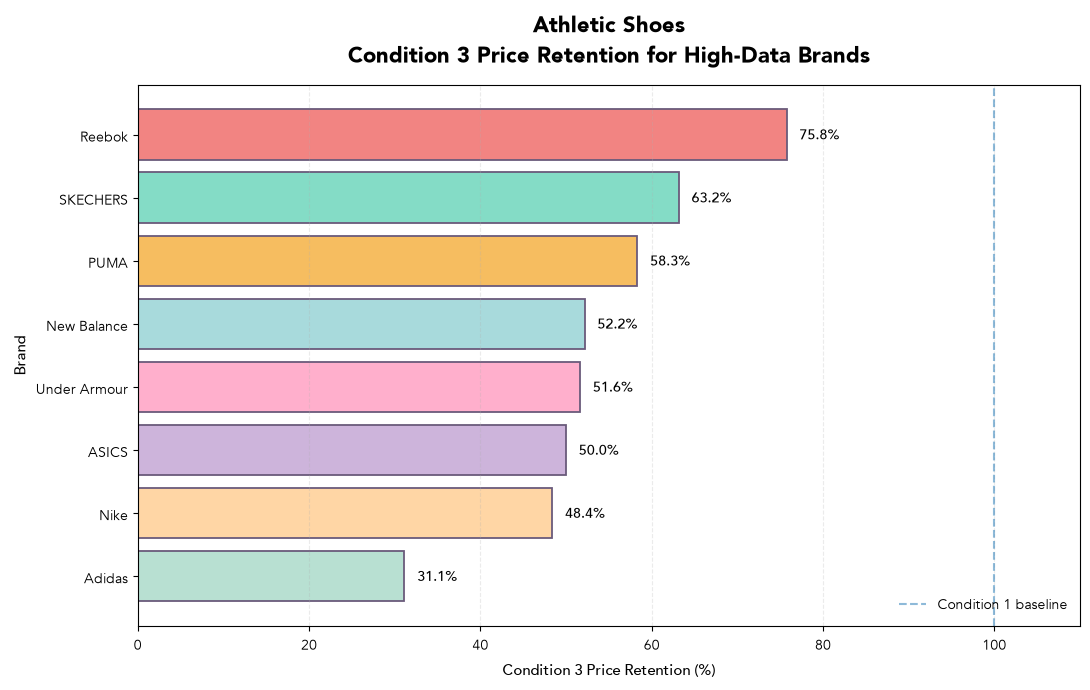

In [159]:
selected_shoe_type = "Athletic"

athletic_profiles = retention[
    (retention["shoe_type"] == selected_shoe_type)
    & retention["condition_3_retention_percent"].notna()
].copy()

athletic_profiles["combined_sample_size"] = (
    athletic_profiles["Condition 1_listing_count"]
    + athletic_profiles["Condition 3_listing_count"]
)

display_brands = (
    athletic_profiles
    .sort_values("combined_sample_size", ascending=False)
    .head(8)
    .sort_values("condition_3_retention_percent")
)

whimsical_colors = [
    "#B8E0D2",
    "#FFD6A5",
    "#CDB4DB",
    "#FFAFCC",
    "#A8DADC",
    "#F6BD60",
    "#84DCC6",
    "#F28482"
]

plt.figure(figsize=(11, 7))

bars = plt.barh(
    display_brands["brand_name"],
    display_brands["condition_3_retention_percent"],
    color=whimsical_colors,
    edgecolor="#6A5A7B",
    linewidth=1.3
)

plt.xlabel(
    "Condition 3 Price Retention (%)",
    fontsize=11,
    fontweight="medium"
)

plt.ylabel(
    "Brand",
    fontsize=11,
    fontweight="medium"
)

plt.title(
    f"{selected_shoe_type} Shoes\nCondition 3 Price Retention for High-Data Brands",
    fontsize=16,
    fontweight="bold",
    pad=16
)

max_value = display_brands["condition_3_retention_percent"].max()

plt.xlim(
    0,
    max(110, max_value + 15)
)

plt.axvline(
    100,
    linestyle="--",
    linewidth=1.5,
    alpha=0.5,
    label="Condition 1 baseline"
)

for bar, value in zip(
    bars,
    display_brands["condition_3_retention_percent"]
):
    plt.text(
        bar.get_width() + 1.5,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=10,
        fontweight="medium"
    )

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

plt.legend(
    frameon=False,
    loc="lower right"
)

plt.tight_layout()
plt.show()

In [160]:
from pathlib import Path

chart_output_dir = Path("../outputs/charts")
chart_output_dir.mkdir(parents=True, exist_ok=True)

shoe_types = [
    "Boots",
    "Sandals",
    "Athletic",
    "Fashion Sneakers",
    "Pumps",
    "Flats",
    "Loafers & Slip-Ons"
]

whimsical_colors = [
    "#7BDFF2",
    "#F7A072",
    "#B8A1E3",
    "#F6BD60",
    "#84DCC6",
    "#F28482",
    "#A8DADC",
    "#CDB4DB"
]

In [161]:
def plot_condition_price_change(
    retention_data,
    shoe_type,
    top_n=8,
    save_chart=True
):
    profiles = retention_data[
        (retention_data["shoe_type"] == shoe_type)
        & retention_data["condition_3_retention_percent"].notna()
    ].copy()

    profiles["combined_sample_size"] = (
        profiles["Condition 1_listing_count"]
        + profiles["Condition 3_listing_count"]
    )

    display_brands = (
        profiles
        .sort_values("combined_sample_size", ascending=False)
        .head(top_n)
        .sort_values("brand_name")
    )

    if display_brands.empty:
        print(f"No qualifying data for {shoe_type}.")
        return

    plt.figure(figsize=(11, 7))

    for color, (_, row) in zip(
        whimsical_colors,
        display_brands.iterrows()
    ):
        plt.plot(
            ["Condition 1", "Condition 3"],
            [
                row["Condition 1_median_price"],
                row["Condition 3_median_price"]
            ],
            marker="o",
            linewidth=2.5,
            markersize=7,
            label=row["brand_name"],
            color=color,
            alpha=0.9
        )

    plt.xlabel(
        "Condition Group",
        fontsize=11,
        fontweight="medium"
    )

    plt.ylabel(
        "Median Listing Price ($)",
        fontsize=11,
        fontweight="medium"
    )

    plt.title(
        f"{shoe_type}\nCondition 1 to Condition 3 Price Changes for High-Data Brands",
        fontsize=16,
        fontweight="bold",
        pad=16
    )

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )

    plt.legend(
        title="High-Data Brands",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False
    )

    plt.tight_layout()

    if save_chart:
        safe_name = (
            shoe_type
            .lower()
            .replace(" ", "_")
            .replace("&", "and")
            .replace("/", "_")
        )

        plt.savefig(
            chart_output_dir
            / f"{safe_name}_condition_1_to_3_prices.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

In [162]:
def plot_condition_3_retention(
    retention_data,
    shoe_type,
    top_n=8,
    save_chart=True
):
    profiles = retention_data[
        (retention_data["shoe_type"] == shoe_type)
        & retention_data["condition_3_retention_percent"].notna()
    ].copy()

    profiles["combined_sample_size"] = (
        profiles["Condition 1_listing_count"]
        + profiles["Condition 3_listing_count"]
    )

    display_brands = (
        profiles
        .sort_values("combined_sample_size", ascending=False)
        .head(top_n)
        .sort_values("condition_3_retention_percent")
    )

    if display_brands.empty:
        print(f"No qualifying data for {shoe_type}.")
        return

    plt.figure(figsize=(11, 7))

    colors = whimsical_colors[:len(display_brands)]

    bars = plt.barh(
        display_brands["brand_name"],
        display_brands["condition_3_retention_percent"],
        color=colors,
        edgecolor="#6A5A7B",
        linewidth=1.3
    )

    plt.xlabel(
        "Condition 3 Price Retention (%)",
        fontsize=11,
        fontweight="medium"
    )

    plt.ylabel(
        "Brand",
        fontsize=11,
        fontweight="medium"
    )

    plt.title(
        f"{shoe_type}\nCondition 3 Price Retention % for High-Data Brands",
        fontsize=16,
        fontweight="bold",
        pad=16
    )

    max_value = display_brands[
        "condition_3_retention_percent"
    ].max()

    plt.xlim(
        0,
        max(110, max_value + 15)
    )

    plt.axvline(
        100,
        linestyle="--",
        linewidth=1.5,
        alpha=0.5,
        label="Condition 1 baseline"
    )

    for bar, value in zip(
        bars,
        display_brands["condition_3_retention_percent"]
    ):
        plt.text(
            bar.get_width() + 1.5,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.1f}%",
            va="center",
            fontsize=10,
            fontweight="medium"
        )

    plt.grid(
        axis="x",
        linestyle="--",
        alpha=0.25
    )

    plt.legend(
        frameon=False,
        loc="lower right"
    )

    plt.tight_layout()

    if save_chart:
        safe_name = (
            shoe_type
            .lower()
            .replace(" ", "_")
            .replace("&", "and")
            .replace("/", "_")
        )

        plt.savefig(
            chart_output_dir
            / f"{safe_name}_condition_3_retention.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

Creating charts for: Boots


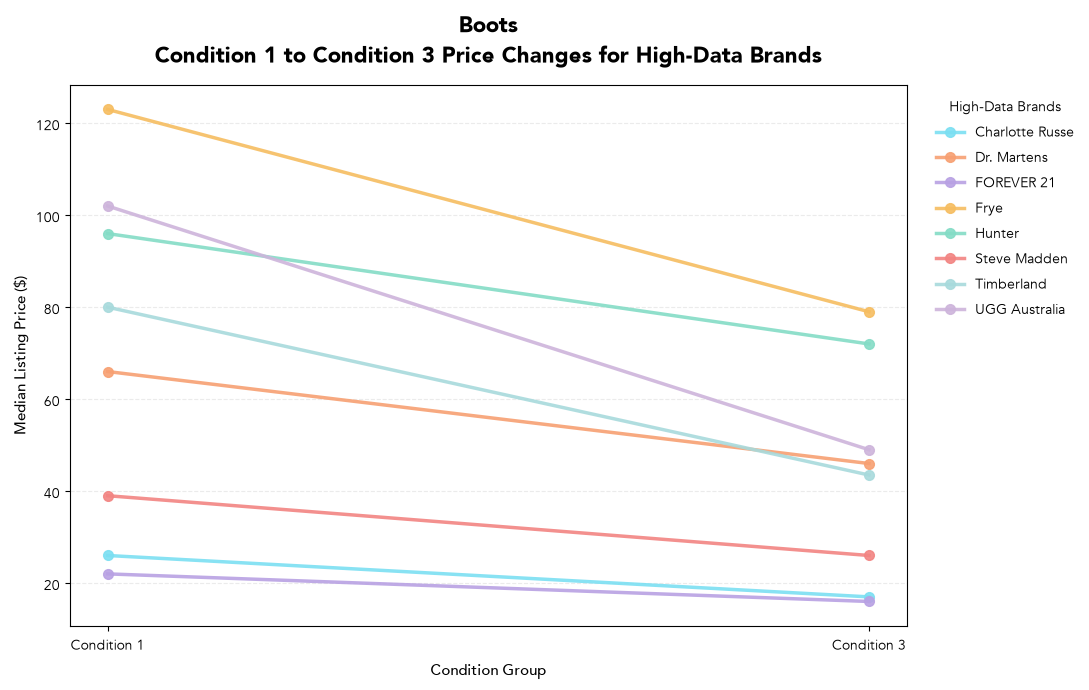

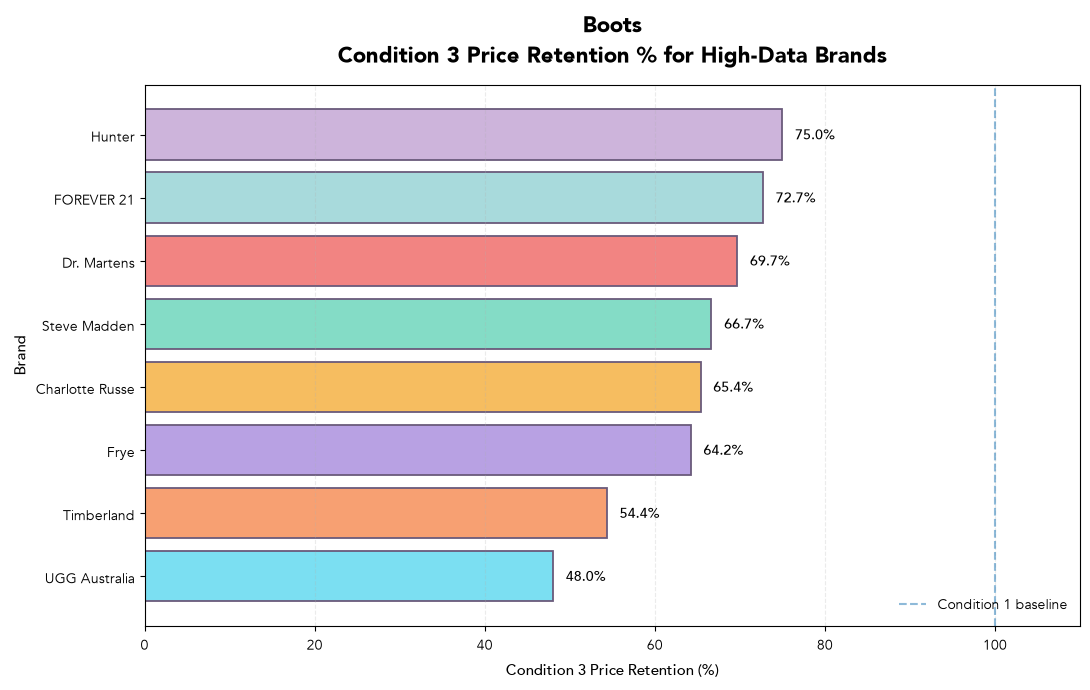

Creating charts for: Sandals


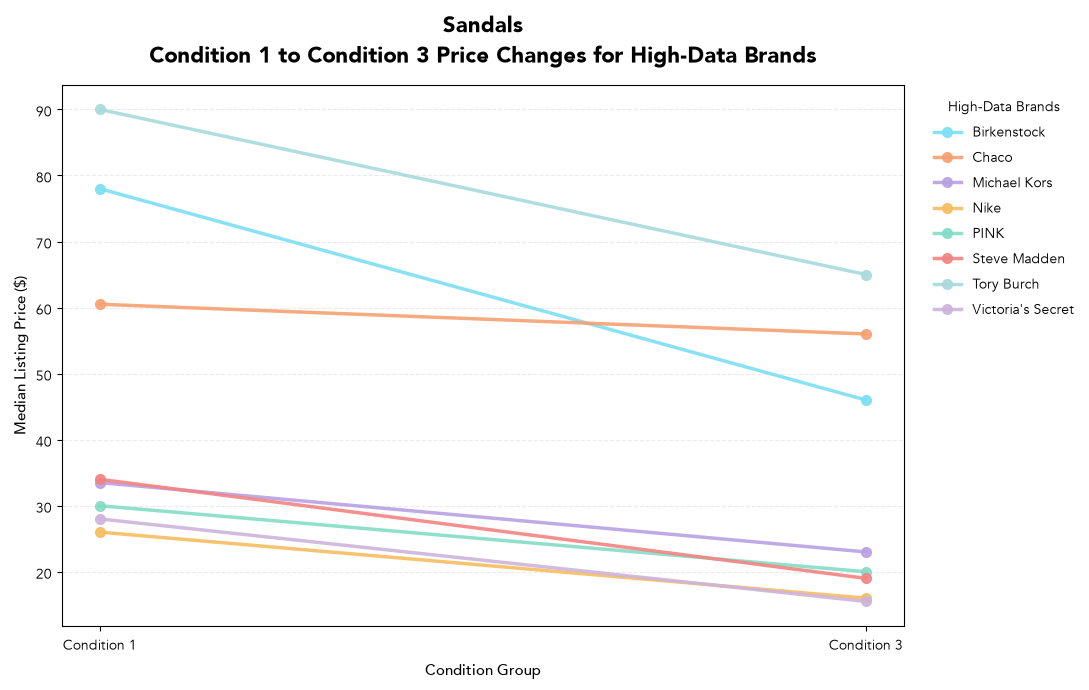

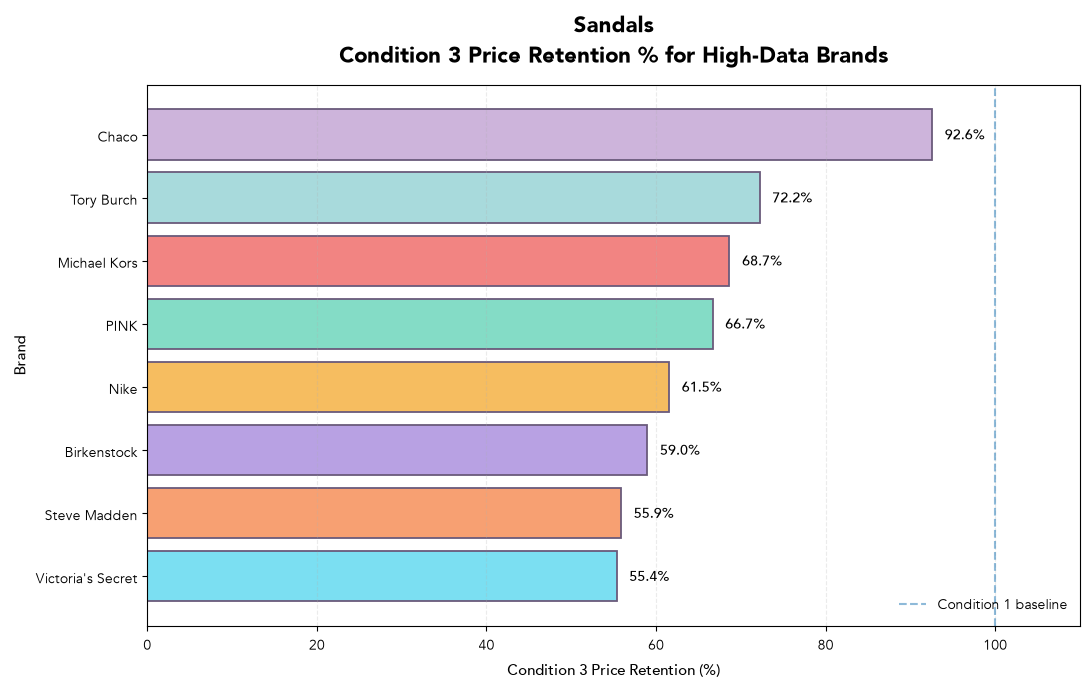

Creating charts for: Athletic


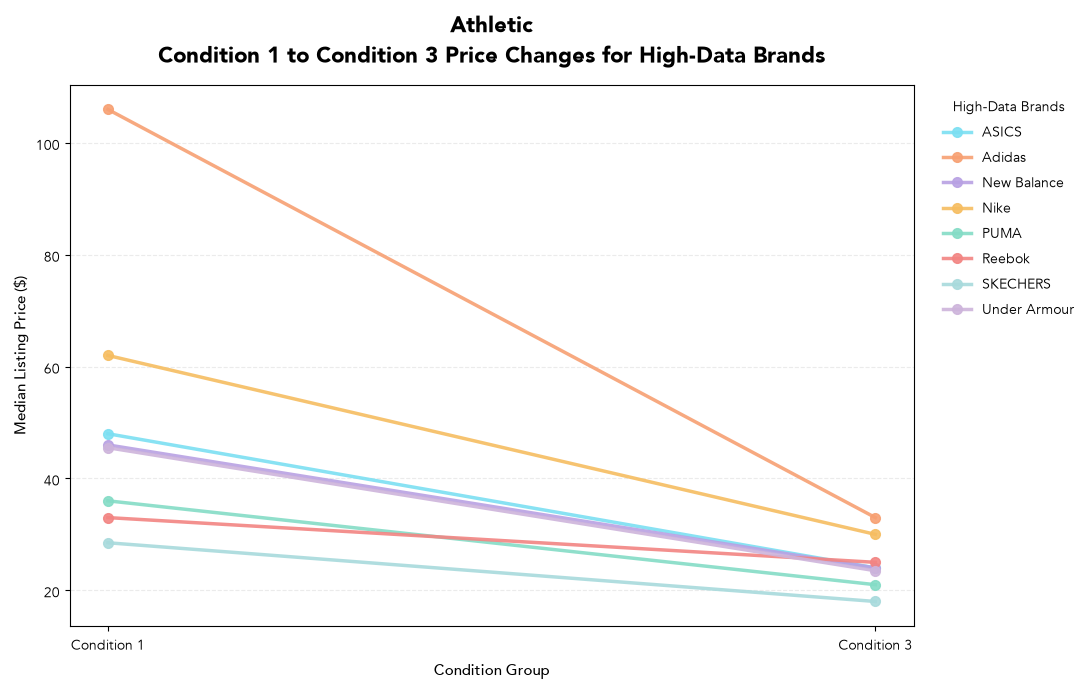

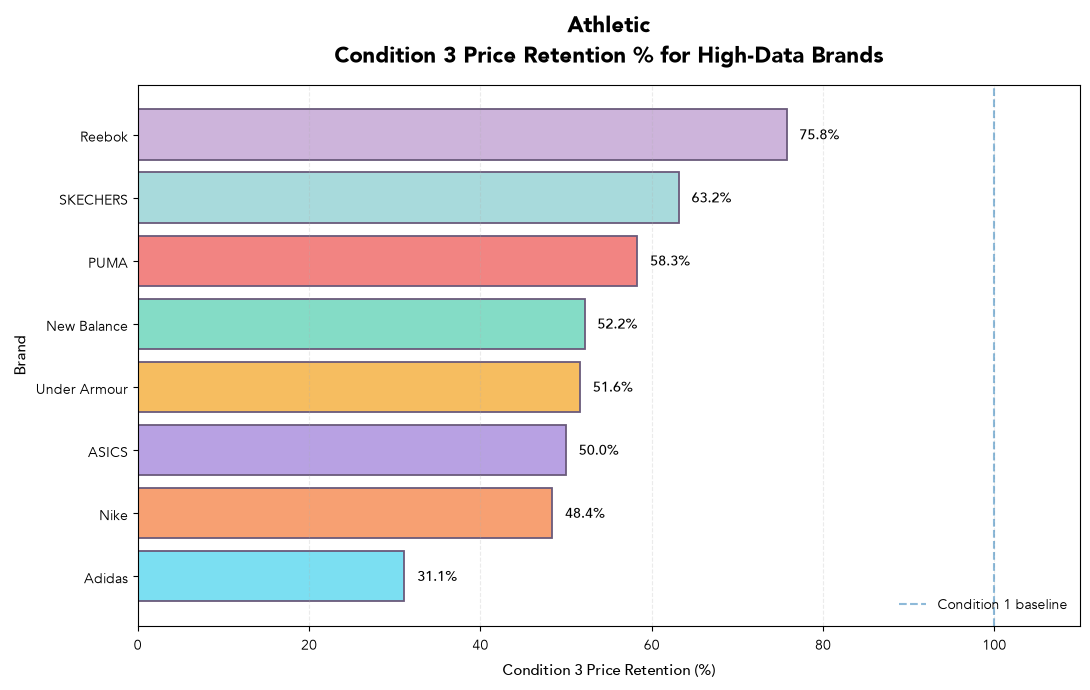

Creating charts for: Fashion Sneakers


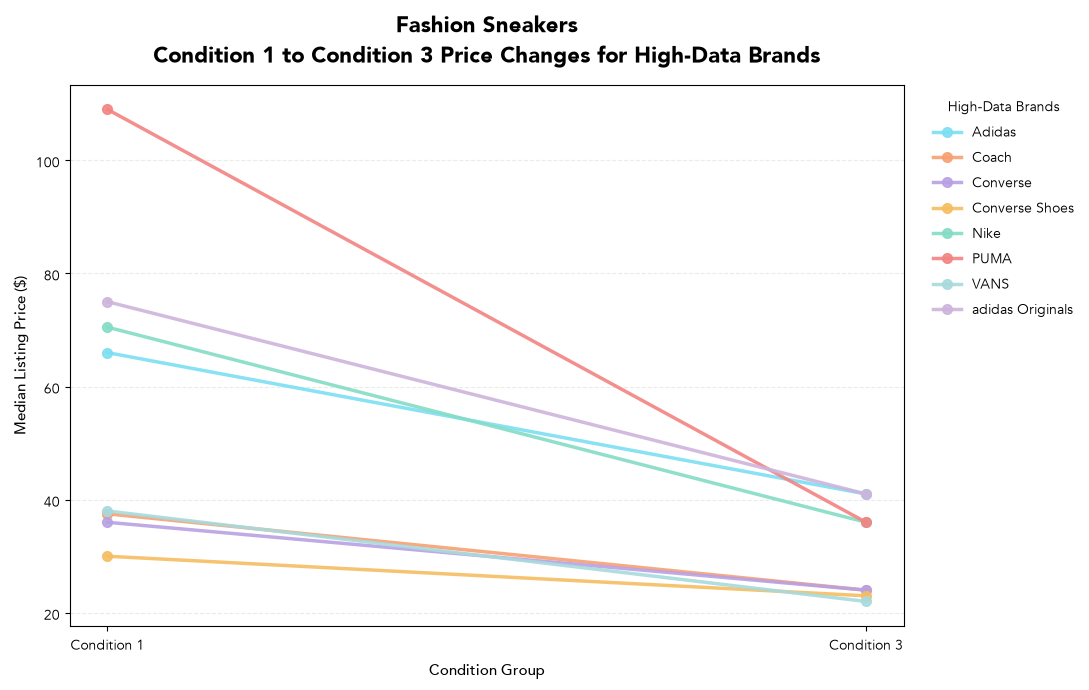

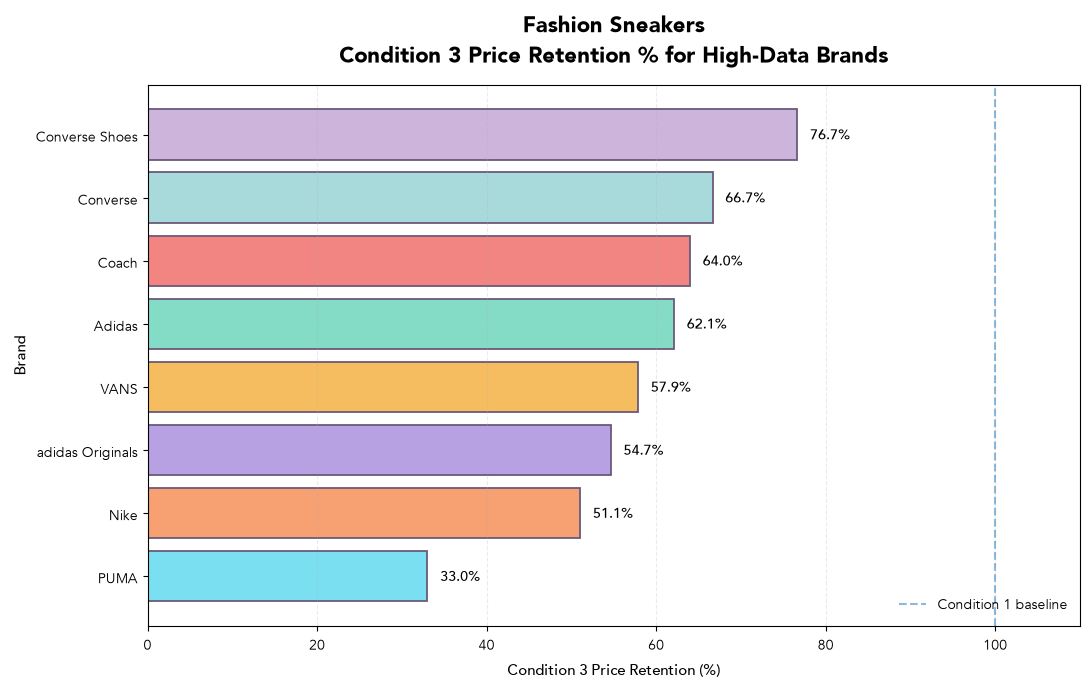

Creating charts for: Pumps


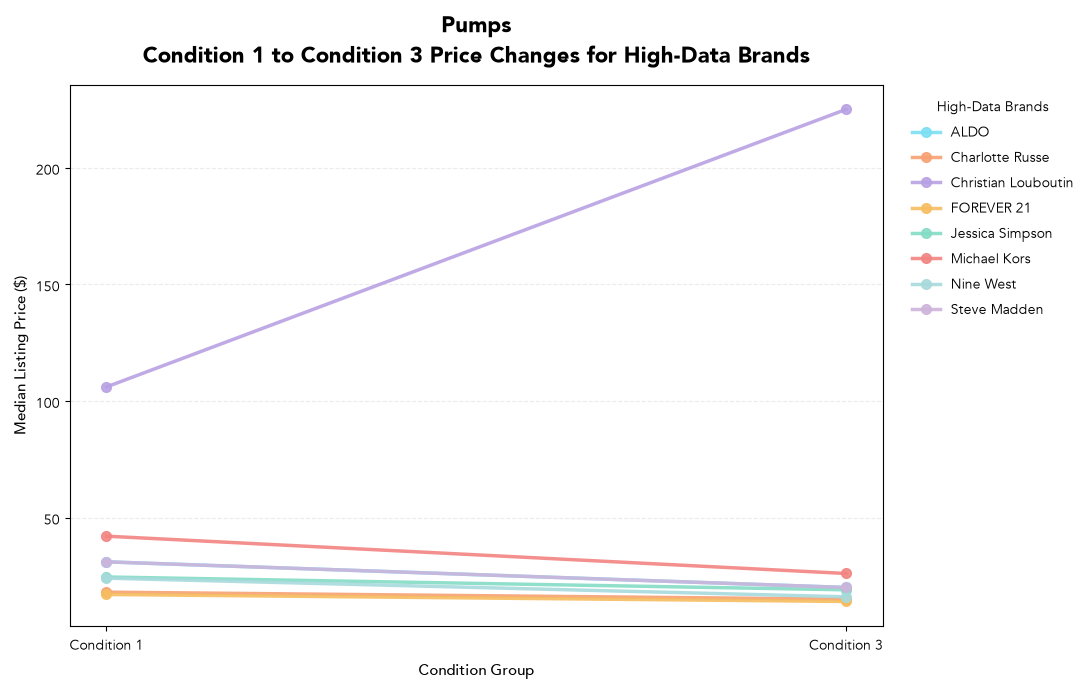

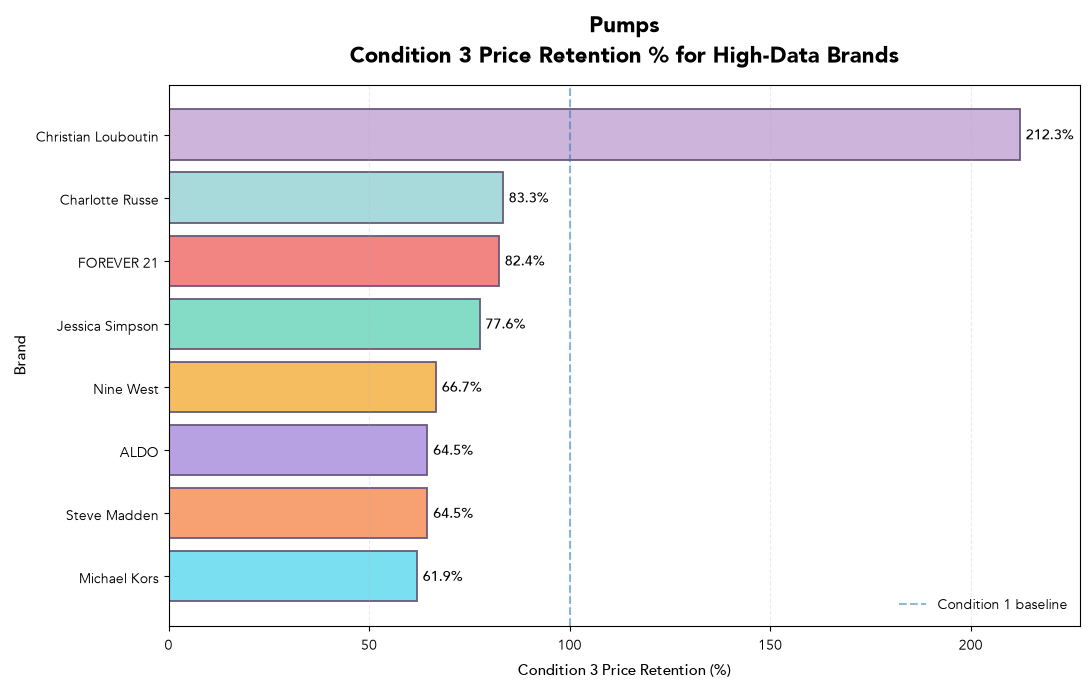

Creating charts for: Flats


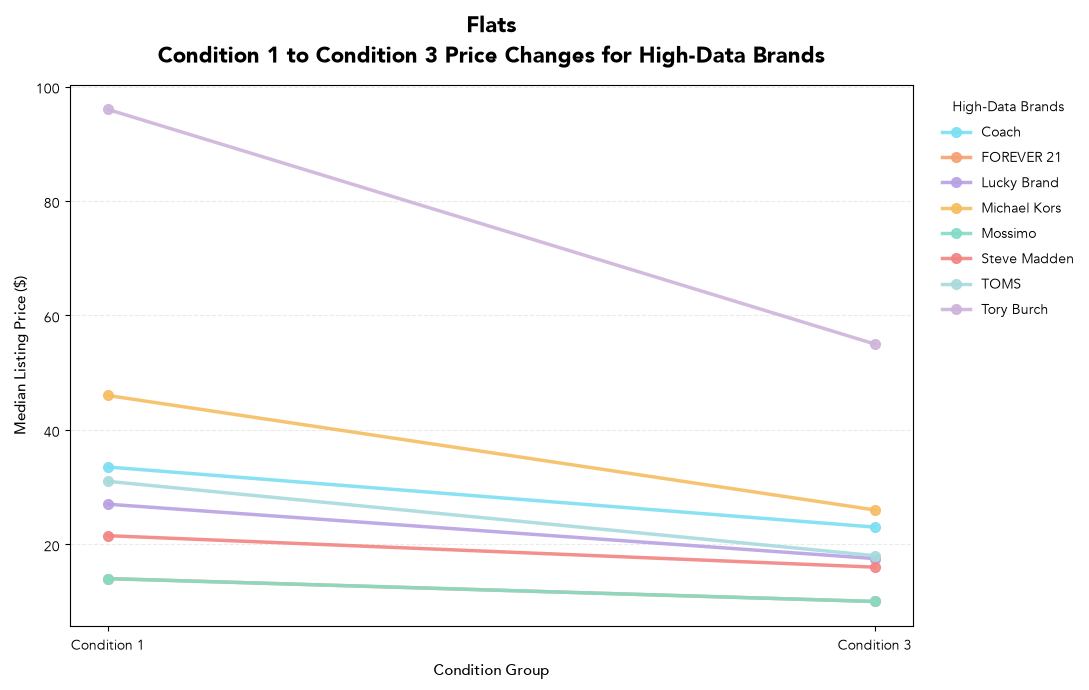

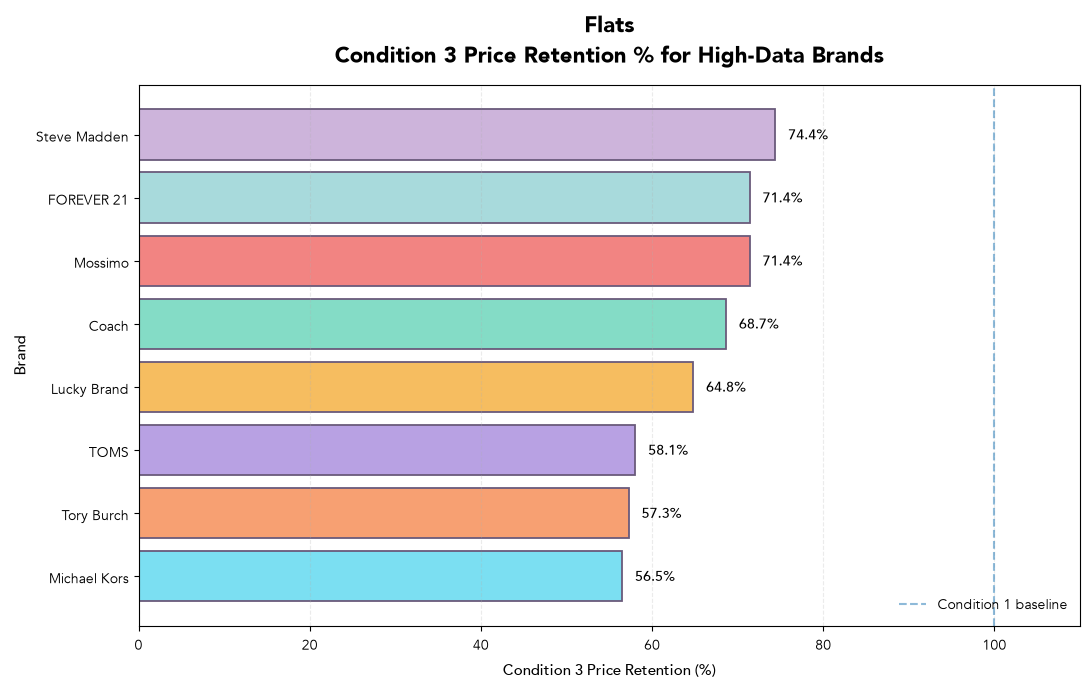

Creating charts for: Loafers & Slip-Ons


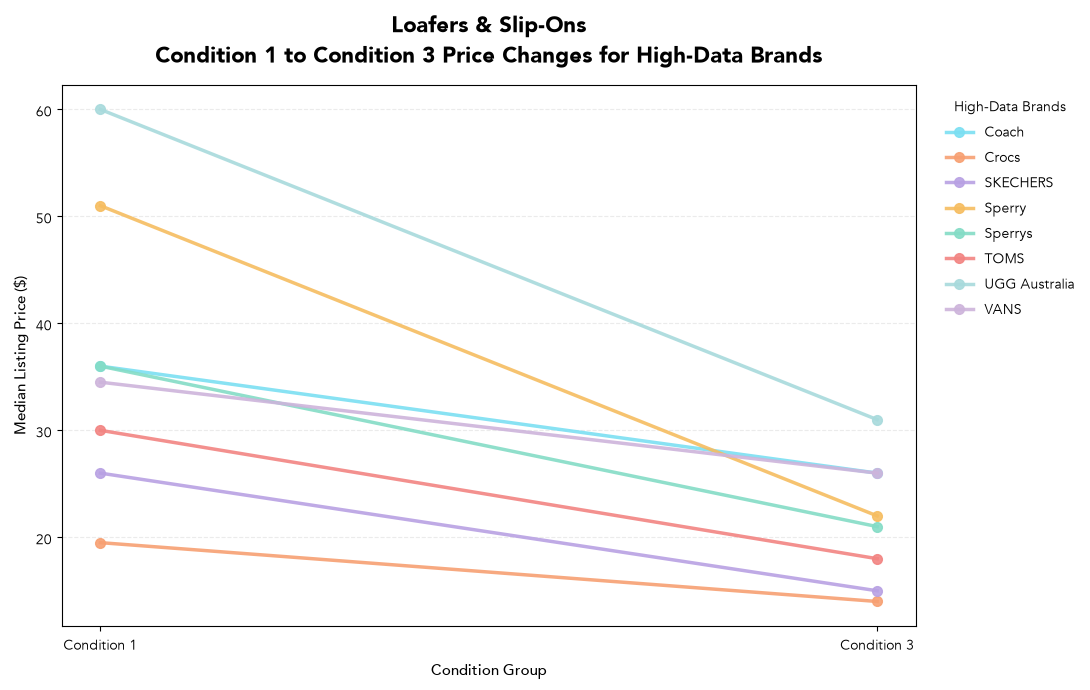

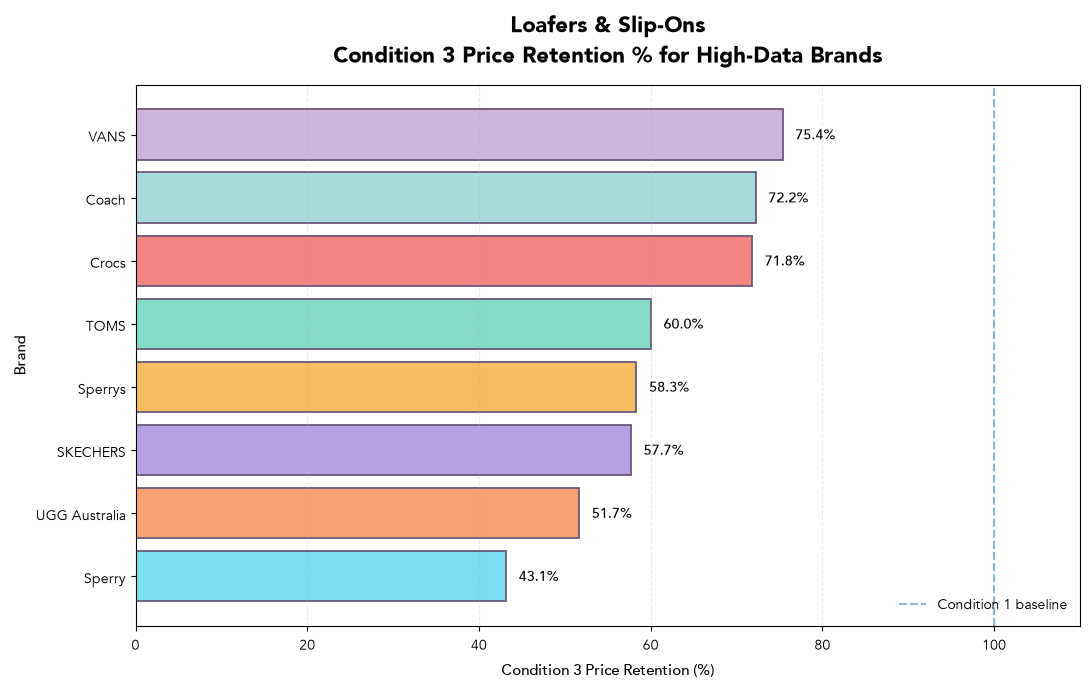

In [163]:
for shoe_type in shoe_types:
    print(f"Creating charts for: {shoe_type}")

    plot_condition_price_change(
        retention,
        shoe_type
    )

    plot_condition_3_retention(
        retention,
        shoe_type
    )